# Phase 2 validation: radial finite-difference eigensolver

Acid test from the plan: with `V(r) = -Z/r` only, eigenvalues from `atomic_scf.solve_radial_channel` must match the analytic hydrogen-like result `E_nl = -Z**2/(2*n**2)` exactly (to discretization error), and the accidental l-degeneracy (e.g. 2s == 2p) must hold.

**Numerical note**: the naive approach of rescaling the generalized eigenproblem to a standard symmetric tridiagonal one (dividing through by `r`, as `eigh_tridiagonal` requires) blows up numerically for small `r_min` — matrix entries reach ~1/r_min^2 and overflow float64's usable dynamic range once r_min gets small enough to resolve heavy-atom core orbitals (r ~ 1/Z). The fix implemented in `atomic_scf.py` is to keep the problem in its natural generalized form `H w = E M w` and solve it via `scipy.sparse.linalg.eigsh` with shift-invert — that factorizes `H - sigma*M` directly (natural-scale entries, no 1/r blowup) instead of forming an explicit `M^{-1/2}` congruence transform.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import atomic_scf as scf
import hydrogenic as hy

## Energy accuracy across Z, l, n

Using `default_grid(Z)` (r_min = 1e-5/Z, r_max = 150, N = 4000).

In [2]:
worst_overall = 0.0
for Z in [1, 2, 10, 30, 60, 90, 100]:
    r, h = scf.default_grid(Z)
    V = -Z / r
    worst = 0.0
    for l in range(4):
        energies, u = scf.solve_radial_channel(r, l, V, h, n_states=4)
        for i, E in enumerate(energies):
            n = l + 1 + i
            E_exact = -Z**2 / (2 * n**2)
            worst = max(worst, abs((E - E_exact) / E_exact))
    worst_overall = max(worst_overall, worst)
    print(f'Z={Z:4d}: worst relative energy error over l=0..3, n=l+1..l+4  ->  {worst:.2e}')
print(f'\nworst error across all tested Z: {worst_overall:.2e}')

Z=   1: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.89e-05
Z=   2: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.89e-05
Z=  10: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.86e-05
Z=  30: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.85e-05
Z=  60: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.84e-05
Z=  90: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.83e-05
Z= 100: worst relative energy error over l=0..3, n=l+1..l+4  ->  3.83e-05

worst error across all tested Z: 3.89e-05


## Accidental l-degeneracy check

For a pure Coulomb potential, states of the same `n` but different `l` must be degenerate (a hallmark of the 1/r potential specifically) — this is a sensitive check that the `(l+1/2)^2` centrifugal term from the log-grid substitution is implemented correctly (an `l(l+1)` vs `l(l-1)`-type bug would show up here as a large, l-dependent splitting).

In [3]:
Z = 10
r, h = scf.default_grid(Z)
V = -Z / r
n = 4
print(f'Z={Z}, n={n}: energies for l=0..{n-1} (should all match -Z**2/(2n**2) = {-Z**2/(2*n**2):.6f})')
for l in range(n):
    energies, u = scf.solve_radial_channel(r, l, V, h, n_states=n - l)
    E_n = energies[n - l - 1]
    print(f'  l={l}: E={E_n:.6f}')

Z=10, n=4: energies for l=0..3 (should all match -Z**2/(2n**2) = -3.125000)
  l=0: E=-3.125015
  l=1: E=-3.125034
  l=2: E=-3.125017
  l=3: E=-3.125004


## Wavefunction shape: numeric vs. analytic

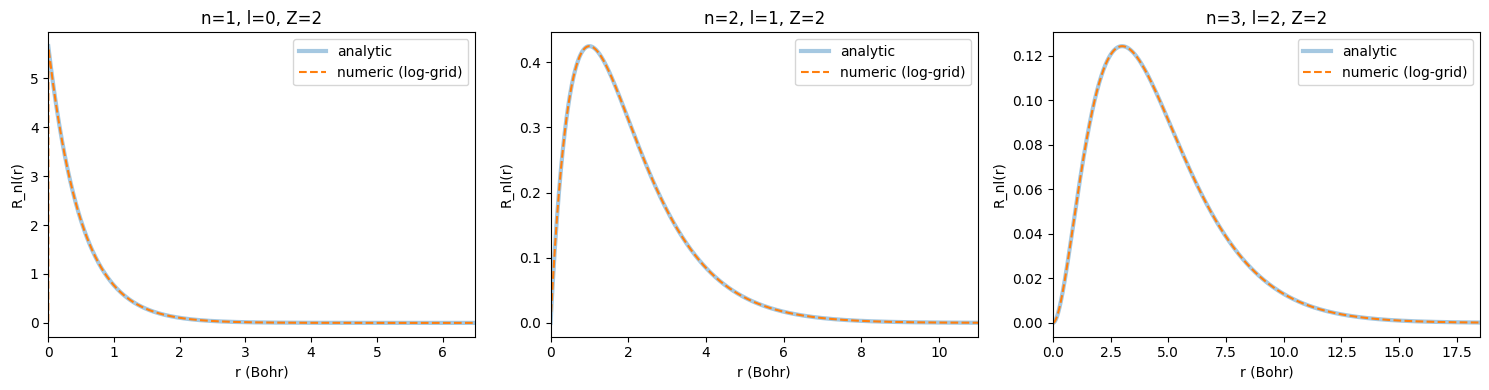

In [4]:
Z = 2
r, h = scf.default_grid(Z)
V = -Z / r

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
cases = [(0, 0), (1, 0), (2, 0)]  # (l, state index within l-channel) -> n = l+1+index
for ax, (l, idx) in zip(axs, cases):
    n = l + 1 + idx
    energies, u = scf.solve_radial_channel(r, l, V, h, n_states=idx + 1)
    R_num = scf.radial_function_from_u(u, r)[:, idx]
    R_ana = hy.radial_wavefunction(n, l, r, Z)
    if np.sign(R_num[np.argmax(np.abs(R_num))]) != np.sign(R_ana[np.argmax(np.abs(R_ana))]):
        R_num = -R_num
    ax.plot(r, R_ana, label='analytic', lw=3, alpha=0.4)
    ax.plot(r, R_num, '--', label='numeric (log-grid)', lw=1.5)
    ax.set_xlim(0, 3 * n**2 / Z + 5)
    ax.set_xlabel('r (Bohr)')
    ax.set_ylabel('R_nl(r)')
    ax.set_title(f'n={n}, l={l}, Z={Z}')
    ax.legend()
plt.tight_layout()
fig.savefig('media/phase2_validation.png', dpi=110)
plt.show()